In [6]:
# mlml1 在mlml版本上稍加修改
# 有三个新增特征/当前输注剂量

In [1]:
# 导入包

In [2]:
import cbr
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
import pandas as pd
from math import sqrt, erf, exp
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn import metrics as me
import GPy
import pickle
from catboost import CatBoostRegressor
import catboost as cb
from sklearn.preprocessing import StandardScaler
import shap
import tensorflow as tf
from sklearn import preprocessing
from tabulate import tabulate

In [ ]:
# 定义函数和全局变量

In [3]:
#全局变量 standardize_catboost 用于控制是否在训练CatBoost模型之前对数据进行标准化处理。
# 如果设置为 True，则在训练前对数值特征进行标准化；如果设置为 False，则不进行标准化。
standardize_catboost = False

In [4]:
# 目标达成预测所需的变量
free_MIC = 2 #未结合最小抑菌浓度
free_toxic_threshold = 12 #未结合毒性阈值
protein_binding = 0.15 # 研究已确定庆大霉素的血浆蛋白结合在 0-30% 之间（DrugBank），取中值、四分位值（常规统计做法）
MIC = free_MIC/(1-protein_binding)
toxic_threshold = free_toxic_threshold/(1-protein_binding)


In [5]:
feature_log = [
   """1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20"""
]

def train_standardizer(array,feature_idx):
    if feature_idx in feature_log:
        if feature_idx == 4 or feature_idx == 2:
            array = np.log(array+1)
        else:
            array = np.log(array)
            
    if feature_idx == 2:
        feature_Scalers[feature_idx] = feature_Scalers[4]
    else:
        feature_Scalers[feature_idx].fit(np.reshape(array,(-1,1)))
    
def Standardize(array,feature_idx):
    if feature_idx in feature_log:
        if feature_idx == 4:
            array = np.log(array+1)
        else:
            array = np.log(array)
    return feature_Scalers[feature_idx].transform(np.reshape(array,(-1,1)))[:,0]
    

def deStandardize(array,XorY,feature):
    if XorY == 'Y':
        return feature_Scalers[2].inverse_transform(np.reshape(array,(-1,1)))[:,0]
        #np.exp(feature_Scalers[23].inverse_transform(np.reshape(array,(-1,1)))[:,0])
    else:
        return feature_Scalers[feature].inverse_transform(np.reshape(array,(-1,1)))[:,0]


In [6]:
# 数据导入和预处理

In [7]:
train_df = pd.read_csv("traintrain.csv")
train_df['time_to_prevCon'] = 0
train_df.loc[train_df.prevCon>0,'time_to_prevCon'] = train_df[train_df.prevCon>0]['Duration']

train_df_new = train_df[train_df.prevCon == 0] 
train_df_prev= train_df[train_df.prevCon > 0] 
Y_prev = train_df_prev.concentration.values
Y_new = train_df_new.concentration.values

validation_pd = pd.read_csv("validationcalidation.csv")
# validation_pd['time_to_prevCon']=np.append(0,validation_pd.Duration[1:].values-validation_pd.Duration[:-1].values)
validation_pd.loc[validation_pd.prevCon==0,'time_to_prevCon'] = 0

# 关于“剂量每小时”（DoseHour）数据的注释，在外部数据集中没有这个数据，所以使用了平均值。
# DoseHour这个特征在最终模型中不是很重要，因此这个处理对模型的影响不大
validation_pd['DoseHour'] = 500

# validation_pd_999 = validation_pd.fillna(-999)
# validation_pd = validation_pd.fillna(validation_pd.mean())

Y_val_un = validation_pd.concentration.values

In [8]:
featureString = {
1:'DoseAdm',
2:'concentration',
3:'Duration',
4:'prevCon',
5:'DoseHour',
6:'Age',
7:'AST',
8:'Calciumnon_ionized',
9:'Serum_Chloride',
10:'Ck_cpk',
11:'Cl8u_eGFR',
12:'Differential_Atypes',
13:'Differential_BANDS',
14:'Drinking',
15:'Gender',
16:'WholeBlood_Glucose',
17:'Serum_Potassium',
18:'Troponin',
19:'Serum_Creatinine',
20:'Weight'
}

featureString_val = {
1:'DoseAdm',
2:'concentration',
3:'Duration',
4:'prevCon',
5:'DoseHour',
6:'Age',
7:'AST',
8:'Calciumnon_ionized',
9:'Serum_Chloride',
10:'Ck_cpk',
11:'Cl8u_eGFR',
12:'Differential_Atypes',
13:'Differential_BANDS',
14:'Drinking',
15:'Gender',
16:'WholeBlood_Glucose',
17:'Serum_Potassium',
18:'Troponin',
19:'Serum_Creatinine',
20:'Weight'
}

feature_Scalers = {
1:StandardScaler(),
2:StandardScaler(),
3:StandardScaler(),
4:StandardScaler(),
5:StandardScaler(),
6:StandardScaler(),
7:StandardScaler(),
8:StandardScaler(),
9:StandardScaler(),
10:StandardScaler(),
11:StandardScaler(),
12:StandardScaler(),
13:StandardScaler(),
14:StandardScaler(),
15:StandardScaler(),
16:StandardScaler(),
17:StandardScaler(),
18:StandardScaler(),
19:StandardScaler(),
20:StandardScaler()
}

In [ ]:
## 外部内部选择和训练集测试集划分

In [9]:
internal_test_bool = False

if internal_test_bool:
    # df2 被更新为只包含至少有一次有效浓度测量（prevCon > 0）的记录
    df2 = train_df.copy(deep=True)
    df2 = df2[df2.prevCon>0].copy(deep=True)

    # 创建一个包含患者测量次数的列表
    patientlist = list(set(df2['PatientID'].tolist()))
    num_of_meas = []
    for patient in patientlist:
        num_of_meas.append(df2[df2['PatientID'] == patient].count()['PatientID'])
    for i in range(0,len(num_of_meas)):
        if num_of_meas[i]>9:
            num_of_meas[i] = 9

    #训练集测试集划分
    patient_train, patient_test = train_test_split(patientlist,test_size = 0.25,stratify=num_of_meas,random_state = 1 )

    df2 = train_df[train_df['PatientID'].isin(patient_test)].copy(deep=True)
    test_df_cbr = df2
    validation_pd = df2
    Y_val_un = validation_pd.concentration.values

    #筛选 train_df 中不在 validation_pd 的 PatientID 中的患者
    # train_df被划分为：①train_df_prev 包含至少有一次有效浓度测量（prevCon > 0）的记录；
    # ② train_df_new 包含没有有效浓度测量（prevCon == 0）的记录
    train_df_split = train_df[~train_df['PatientID'].isin(validation_pd.PatientID)].copy(deep=True)
    train_df_prev = train_df_split[train_df_split.prevCon > 0].copy(deep=True)
    train_df_new = train_df_split[train_df_split.prevCon == 0].copy(deep=True)
    train_df_tot = train_df_split.copy(deep=True)
    
    # CatBoost模型训练集测试集
    train_df_cbr_prev = train_df_prev.copy(deep=True)
    train_df_cbr_new = train_df_new.copy(deep=True)
    #Prev = A posteriori test
    test_df_cbr_prev = validation_pd[validation_pd.prevCon > 0]
    #New = A priori test
    test_df_cbr_new = validation_pd[validation_pd.prevCon >= 0].copy(deep=True)
    # test_df_cbr_new = validation_pd[validation_pd.prevCon == 0].copy(deep=True)

    # var_mode是本文中的CBR-New模型，之前的“新”数据集是针对GP-New的。由于两者使用不同的数据集，因此名称不同
    train_df_cbr_var = train_df_split[(train_df_split.prevCon==0)|((train_df_split.prevCon > 0) & (np.abs(train_df_split.concentration_diff)>10))].copy(deep=True)
    test_df_cbr_var = validation_pd[validation_pd.prevCon>=0]
    Y_val_popPK = test_df_cbr.copy(deep=True).concentration.values
    
else:
    train_df_tot = train_df.copy(deep=True)
    test_df_cbr = validation_pd
    test_df_cbr_prev = validation_pd.copy(deep=True)
    train_df_cbr_prev = train_df_prev.copy(deep=True)
    train_df_cbr_new = train_df_new.copy(deep=True)
    test_df_cbr_prev = validation_pd[validation_pd.prevCon > 0].copy(deep=True)
    test_df_cbr_new = validation_pd[validation_pd.prevCon >= 0].copy(deep=True)
    train_df_cbr_var = train_df[(train_df.prevCon==0)|((train_df.prevCon > 0) & (train_df.concentration_diff>10))].copy(deep=True)
    test_df_cbr_var = validation_pd[validation_pd.prevCon>=0].copy(deep=True)

val_pd_new = validation_pd[validation_pd.prevCon >= 0].copy(deep=True)
val_pd_prev = validation_pd[validation_pd.prevCon > 0].copy(deep=True)
val_pd_tot = validation_pd.copy(deep=True)
val_pd_tot_nostand = validation_pd.copy(deep=True)
Y_val_new = val_pd_new.concentration.values
Y_val_prev = val_pd_prev.concentration.values
Y_prev = train_df_prev.concentration.values
Y_new = train_df_new.concentration.values

In [2]:
from sklearn.preprocessing import StandardScaler

noprev_df = train_df[train_df.prevCon>0].copy(deep=True)

train_df_prev_temp = train_df_prev.copy(deep=True)
train_df_new_temp = train_df_new.copy(deep=True)

# 创建一个标准化器的字典，用于不同的特征
scalers = {}

# 对于训练集中的每个特征进行标准化
for i in range(1, 19):
    feat = featureString[i]
    feat_val = featureString_val[i]

    # 创建一个新的 StandardScaler 实例，并将其存储在字典中
    scalers[i] = StandardScaler()

    # 对 noprev_df 中的特征进行标准化
    noprev_df[feat] = scalers[i].transform(noprev_df[feat].values.reshape(-1, 1))

    # 对 train_df_prev_temp 和 train_df_new_temp 进行相同的标准化
    train_df_prev_temp[feat] = scalers[i].transform(train_df_prev[feat].values.reshape(-1, 1))
    train_df_new_temp[feat] = scalers[i].transform(train_df_new[feat].values.reshape(-1, 1))

    # # 如果需要对 CatBoost 的特征进行标准化
    # if standardize_catboost:
    #     train_df_cbr[feat] = scalers[i].transform(train_df_cbr[feat].values.reshape(-1, 1))
    #     print("boo")

    # 对测试集或验证集进行标准化
    if internal_test_bool:
        if standardize_catboost:
            test_df_cbr[feat] = scalers[i].transform(test_df_cbr[feat].values.reshape(-1, 1))
        val_pd_tot[feat] = scalers[i].transform(val_pd_tot[feat].values.reshape(-1, 1))
        val_pd_new[feat] = scalers[i].transform(val_pd_new[feat].values.reshape(-1, 1))
        val_pd_prev[feat] = scalers[i].transform(val_pd_prev[feat].values.reshape(-1, 1))
    else:
        if feat_val != 'NO':
            if standardize_catboost:
                test_df_cbr[feat_val] = scalers[i].transform(test_df_cbr[feat_val].values.reshape(-1, 1))
            val_pd_new[feat_val] = scalers[i].transform(val_pd_new[feat_val].values.reshape(-1, 1))
            val_pd_prev[feat_val] = scalers[i].transform(val_pd_prev[feat_val].values.reshape(-1, 1))

# 复制新的标准化后的数据
train_df_new = train_df_new_temp.copy(deep=True)
train_df_prev = train_df_prev_temp.copy(deep=True) 

# 获取目标变量的值
Y_prev = train_df_prev['concentration'].values
Y_val_new = val_pd_new['concentration'].values
Y_val_prev = val_pd_prev['concentration'].values
Y_val_tot = val_pd_tot['concentration'].values
Y_new = train_df_new['concentration'].values


NameError: name 'train_df' is not defined

In [13]:
Y_cbr_test_new = test_df_cbr_new['concentration'].values
Y_cbr_test_prev = test_df_cbr_prev['concentration'].values

Y_cbr_test = validation_pd['concentration'].values/validation_pd['DoseHour'].values


Y_cbr_train_new = train_df_cbr_new['concentration'].values
Y_cbr_train_prev = train_df_cbr_prev['concentration'].values

Y_cbr_train_var = train_df_cbr_var['concentration'].values
Y_cbr_test_var = test_df_cbr_var['concentration'].values

In [14]:
# Data shape fixing
Y_prev = np.reshape(Y_prev,(-1,1))
Y_new = np.reshape(Y_new,(-1,1))
Y_val_un = np.reshape(Y_val_un,(-1,1))

In [15]:
if not internal_test_bool:
    val_pd_new = val_pd_new.rename(columns={"Cl8u_-999": "Cl8u"})
    val_pd_prev = val_pd_prev.rename(columns={"Cl8u_-999": "Cl8u"})

In [ ]:
# 模型

In [ ]:
## 预处理

In [16]:
# 为连续浓度设定目标达成等级
def to_pred_classes(Y_prediction,stand):
    if stand:
        class_t = deStandardize(Y_prediction[0],'Y',-1)
    else:
        class_t = Y_prediction
    class_pred = []
    for el in class_t:
        if el < 4*MIC:
            class_pred = np.append(class_pred,"U")#Underdosing")
        elif el < toxic_threshold:
            class_pred = np.append(class_pred,"A")#dequate dosing")
        else:
            class_pred = np.append(class_pred,"O")#verdosing")
    return class_pred

def get_X_features(features,X):
    return  X[features].astype(np.float32).to_numpy()

In [25]:
## CatBoost

In [17]:
preprocessed_columns_prev = ['DoseAdm', 'concentration', 'Duration', 'prevCon', 'DoseHour', 'Age', 'AST', 'Calciumnon_ionized', 'Serum_Chloride', 'Ck_cpk', 'Cl8u_eGFR', 'Differential_Atypes', 'Differential_BANDS', 'Drinking', 'Gender', 'WholeBlood_Glucose', 'Serum_Potassium', 'Troponin', 'Serum_Creatinine', 'Weight']

preprocessed_columns_var = ['DoseAdm', 'concentration', 'Duration', 'prevCon', 'DoseHour', 'Age', 'AST', 'Calciumnon_ionized', 'Serum_Chloride', 'Ck_cpk', 'Cl8u_eGFR', 'Differential_Atypes', 'Differential_BANDS', 'Drinking', 'Gender', 'WholeBlood_Glucose', 'Serum_Potassium', 'Troponin', 'Serum_Creatinine', 'Weight']
          
X_columns_prev = np.concatenate([preprocessed_columns_prev])
X_cbr_train_prev = train_df_cbr_prev[X_columns_prev]
X_cbr_test_prev = test_df_cbr_prev[X_columns_prev]

X_columns_var = np.concatenate([preprocessed_columns_var])
X_cbr_train_var = train_df_cbr_var[X_columns_var]
X_cbr_test_var = test_df_cbr_var[X_columns_var]

In [18]:
cat_cols_prev = list(X_cbr_train_prev.select_dtypes(include='object').columns)
cat_cols_idx_prev = []
for col_idx, col in enumerate(X_cbr_train_prev.columns):
     if col in cat_cols_prev:
            cat_cols_idx_prev.append(col_idx)
            
cat_cols_var = list(X_cbr_train_var.select_dtypes(include='object').columns)
cat_cols_idx_var = []
for col_idx, col in enumerate(X_cbr_train_var.columns):
     if col in cat_cols_var:
            cat_cols_idx_var.append(col_idx)

In [19]:
from scipy.special import erfinv
from math import sqrt, erf

# 指定覆盖率 Quantile_size_prev, q_size_new, q_size_var
# 计算与覆盖率对应的分位数倍数 mult_quantile_prev, mult_quantile_new, mult_quantile_var
Quantile_size_prev = 0.88
mult_quantile_prev = erfinv(Quantile_size_prev)*sqrt(2)
q_size_new = 0.9
mult_quantile_new = erfinv(q_size_new)*sqrt(2)
q_size_var = 0.88#0.879
mult_quantile_var = erfinv(q_size_var)*sqrt(2)

In [20]:
#Iteration Hyperparameter
if internal_test_bool:
    it_q50_prev = 336
    it_qlow_prev = 202
    it_qhigh_prev = 166
    it_q50_new = 430
    it_qlow_new = 165
    it_qhigh_new = 177
else:    
    it_q50_prev = 273
    it_qlow_prev = 236
    it_qhigh_prev = 142
    it_q50_new = 236
    it_qlow_new = 172
    it_qhigh_new = 145

In [21]:
if internal_test_bool:
    it_q50_var = 388#245
    it_qlow_var = 119#118
    it_qhigh_var = 158#93
else:
    it_q50_var = 359
    it_qlow_var = 182
    it_qhigh_var = 167

In [22]:
# 低分位数和高分位数模型的定义和训练-训练prev相关模型
cbr_quant_low_prev = CatBoostRegressor(
    random_seed=42,
    verbose=False,
    one_hot_max_size=5,
    loss_function='Quantile:alpha=' + str(0.50 - Quantile_size_prev / 2),
    iterations=it_qlow_prev,
    use_best_model=False,
    depth=3,
    l2_leaf_reg=7,
    border_count=187,
    boost_from_average=False
)
cbr_quant_low_prev.fit(X_cbr_train_prev, Y_cbr_train_prev, eval_set=(X_cbr_test_prev, Y_cbr_test_prev))

cbr_quant_high_prev = CatBoostRegressor(
    random_seed=42,
    verbose=False,
    one_hot_max_size=5,
    loss_function='Quantile:alpha=' + str(0.50 + Quantile_size_prev / 2),
    iterations=it_qhigh_prev,
    use_best_model=False,
    depth=3,
    l2_leaf_reg=7,
    border_count=187,
    boost_from_average=False
)
cbr_quant_high_prev.fit(X_cbr_train_prev, Y_cbr_train_prev, eval_set=(X_cbr_test_prev, Y_cbr_test_prev))


In [23]:
# 低分位数和高分位数模型的定义和训练-训练prev相关模型
cbr_quant_low_var = CatBoostRegressor(
    random_seed=42,
    verbose=False,
    one_hot_max_size=5,
    loss_function='Quantile:alpha=' + str(0.50 - q_size_var / 2),
    iterations=it_qlow_var,
    use_best_model=False,
    depth=4,
    l2_leaf_reg=12,
    border_count=213,
    boost_from_average=False
)
cbr_quant_low_var.fit(X_cbr_train_var, Y_cbr_train_var, cat_features=cat_cols_var, eval_set=(X_cbr_test_var, Y_cbr_test_var))

cbr_quant_high_var = CatBoostRegressor(
    random_seed=42,
    verbose=False,
    one_hot_max_size=5,
    loss_function='Quantile:alpha=' + str(0.50 + q_size_var / 2),
    iterations=it_qhigh_var,
    use_best_model=False,
    depth=4,
    l2_leaf_reg=12,
    border_count=213,
    boost_from_average=False
)
cbr_quant_high_var.fit(X_cbr_train_var, Y_cbr_train_var, cat_features=cat_cols_var, eval_set=(X_cbr_test_var, Y_cbr_test_var))


In [24]:
y_pred_test_cbr_low_prev = cbr_quant_low_prev.predict(X_cbr_test_prev)
y_pred_test_cbr_high_prev = cbr_quant_high_prev.predict(X_cbr_test_prev)

In [25]:
# 用于 var 数据的标准差计算
y_pred_test_cbr_low_var = cbr_quant_low_var.predict(X_cbr_test_var)
y_pred_test_cbr_high_var = cbr_quant_high_var.predict(X_cbr_test_var)
# 计算高斯分布的标准差，用于描述预测结果的波动程度，以量化预测的不确定性
y_pred_sigm_var = np.subtract(y_pred_test_cbr_high_var,y_pred_test_cbr_low_var)/(2*mult_quantile_var)

In [26]:
# 用于 prev 数据的标准差计算
y_var_train_low = cbr_quant_low_var.predict(X_cbr_train_var)
y_var_train_high = cbr_quant_high_var.predict(X_cbr_train_var)
var_sigma_train = np.subtract(y_var_train_high,y_var_train_low)/(2*mult_quantile_var)

y_prev_train_low = cbr_quant_low_prev.predict(X_cbr_train_prev)
y_prev_train_high = cbr_quant_high_prev.predict(X_cbr_train_prev)
prev_sigma_train = np.subtract(y_prev_train_high,y_prev_train_low)/(2*mult_quantile_prev)

In [27]:
y_pred_sigm_prev = np.subtract(y_pred_test_cbr_high_prev,y_pred_test_cbr_low_prev)/(2*mult_quantile_prev)

In [28]:
cbr_prev = CatBoostRegressor(random_seed=42, verbose=False, one_hot_max_size=5, loss_function='Quantile:alpha=0.5',
                                iterations=it_q50_prev, use_best_model=False, depth = 3,l2_leaf_reg=7,border_count=187,boost_from_average=False)

cbr_prev.fit(X_cbr_train_prev, Y_cbr_train_prev, cat_features=cat_cols_prev, eval_set=(X_cbr_test_prev, Y_cbr_test_prev))


In [29]:
# 将false的boost_from_average值提升到0.17.5
cbr_var = CatBoostRegressor(random_seed=42, verbose=False, one_hot_max_size=5, loss_function='Quantile:alpha=0.5',
                                iterations=it_q50_var, use_best_model=False, depth = 4,l2_leaf_reg=12,border_count=213,bootstrap_type='Bayesian',boost_from_average=False)
cbr_var.fit(X_cbr_train_var, Y_cbr_train_var, cat_features=cat_cols_idx_var, eval_set=(X_cbr_test_var, Y_cbr_test_var))

In [30]:
y_pred_test_cbr_var = cbr_var.predict(X_cbr_test_var)

In [36]:
#Y_cbr_train_var
cbr_var_train_pred = cbr_var.predict(X_cbr_train_var)
#Y_cbr_train_prev
cbr_prev_train_pred = cbr_prev.predict(X_cbr_train_prev)

In [37]:
if standardize_catboost:
    y_pred_test_cbr = deStandardize(cbr.predict(X_cbr_test),'Y',-1)
else:
    y_pred_test_cbr_prev = cbr_prev.predict(X_cbr_test_prev)

if standardize_catboost:
    y_pred_train_cbr = deStandardize(cbr.predict(X_cbr_train),'Y',-1)
else:
    y_pred_test_cbr_prev = cbr_prev.predict(X_cbr_test_prev)

if standardize_catboost:
    Y_cbr_test_dest = deStandardize(Y_cbr_test,'Y',-1)
else:
    Y_cbr_test_dest = Y_cbr_test

In [38]:
import pandas as pd

# 对 prev 数据集的结果进行整理
results_prev = pd.DataFrame({
    'Observed (prev)': Y_cbr_test_prev,                # 观测值
    'Predicted Mean (prev)': y_pred_test_cbr_prev,     # 均值预测（通过alpha=0.5模型得到）
    'Lower Bound (prev)': y_pred_test_cbr_low_prev,    # 低分位数预测
    'Upper Bound (prev)': y_pred_test_cbr_high_prev,   # 高分位数预测
    'Predicted Sigma (prev)': y_pred_sigm_prev         # 标准差
})

# 保存 prev 数据集结果为 CSV 文件
results_prev.to_csv('observed_and_predictions_prev.csv', index=False, encoding='utf-8-sig')
print("prev 数据集的观测数据与预测结果已保存为 'observed_and_predictions_prev.csv' 文件")

# 对 var 数据集的结果进行整理
results_var = pd.DataFrame({
    'Observed (var)': Y_cbr_test_var,                  # 观测值
    'Predicted Mean (var)': y_pred_test_cbr_var,       # 均值预测（通过alpha=0.5模型得到）
    'Lower Bound (var)': y_pred_test_cbr_low_var,      # 低分位数预测
    'Upper Bound (var)': y_pred_test_cbr_high_var,     # 高分位数预测
    'Predicted Sigma (var)': y_pred_sigm_var           # 标准差
})

# 保存 var 数据集结果为 CSV 文件
results_var.to_csv('observed_and_predictions_var.csv', index=False, encoding='utf-8-sig')
print("var 数据集的观测数据与预测结果已保存为 'observed_and_predictions_var.csv' 文件")


prev 数据集的观测数据与预测结果已保存为 'observed_and_predictions_prev.csv' 文件
var 数据集的观测数据与预测结果已保存为 'observed_and_predictions_var.csv' 文件


In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 加载数据
data_file_path = 'observed_and_predictions_prev.csv'
data = pd.read_csv(data_file_path)

# 提取观测值和预测值
observed = data['Observed (prev)']
predicted = data['Predicted Mean (prev)']

# 计算 RMSE（均方根误差）
rmse = np.sqrt(mean_squared_error(observed, predicted))

# 计算 MAE（平均绝对误差）
mae = mean_absolute_error(observed, predicted)

# 计算 MdAE（中位数绝对误差）
mdae = np.median(np.abs(observed - predicted))

# 计算 R²（决定系数）
r_squared = r2_score(observed, predicted)

# 计算 ME（平均误差）
me = np.mean(observed - predicted)

# 计算 MdAPE（中位数绝对百分比误差）
mdape = np.median(np.abs((observed - predicted) / observed) * 100)

# 计算 MdPE（中位数百分比误差）
mdpe = np.median((observed - predicted) / observed * 100)

# 计算标准差（Std） of 预测误差
std = np.std(observed - predicted)

# 输出结果
print("prev模型结果")
print(f"RMSE: {rmse:.10f}")
print(f"MAE: {mae:.4f}")
print(f"MdAE: {mdae:.4f}")
print(f"R²: {r_squared:.4f}")
print(f"ME: {me:.4f}")
print(f"MdAPE: {mdape:.4f}%")
print(f"MdPE: {mdpe:.4f}%")
print(f"Std: {std:.4f}")


prev模型结果
RMSE: 0.1605029713
MAE: 0.0914
MdAE: 0.0477
R²: 0.9898
ME: 0.0087
MdAPE: 14.0541%
MdPE: 5.6416%
Std: 0.1603


In [40]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 加载数据
data_file_path = 'observed_and_predictions_var.csv'
data = pd.read_csv(data_file_path)

# 提取观测值和预测值
observed = data['Observed (var)']
predicted = data['Predicted Mean (var)']

# 计算 RMSE（均方根误差）
rmse = np.sqrt(mean_squared_error(observed, predicted))

# 计算 MAE（平均绝对误差）
mae = mean_absolute_error(observed, predicted)

# 计算 MdAE（中位数绝对误差）
mdae = np.median(np.abs(observed - predicted))

# 计算 R²（决定系数）
r_squared = r2_score(observed, predicted)

# 计算 ME（平均误差）
me = np.mean(observed - predicted)

# 计算 MdAPE（中位数绝对百分比误差）
mdape = np.median(np.abs((observed - predicted) / observed) * 100)

# 计算 MdPE（中位数百分比误差）
mdpe = np.median((observed - predicted) / observed * 100)

# 计算标准差（Std） of 预测误差
std = np.std(observed - predicted)

# 输出结果
print("var模型结果")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MdAE: {mdae:.4f}")
print(f"R²: {r_squared:.4f}")
print(f"ME: {me:.4f}")
print(f"MdAPE: {mdape:.4f}%")
print(f"MdPE: {mdpe:.4f}%")
print(f"Std: {std:.4f}")


var模型结果
RMSE: 0.7145
MAE: 0.2242
MdAE: 0.0621
R²: 0.9207
ME: 0.1795
MdAPE: 10.8146%
MdPE: 9.4012%
Std: 0.6916


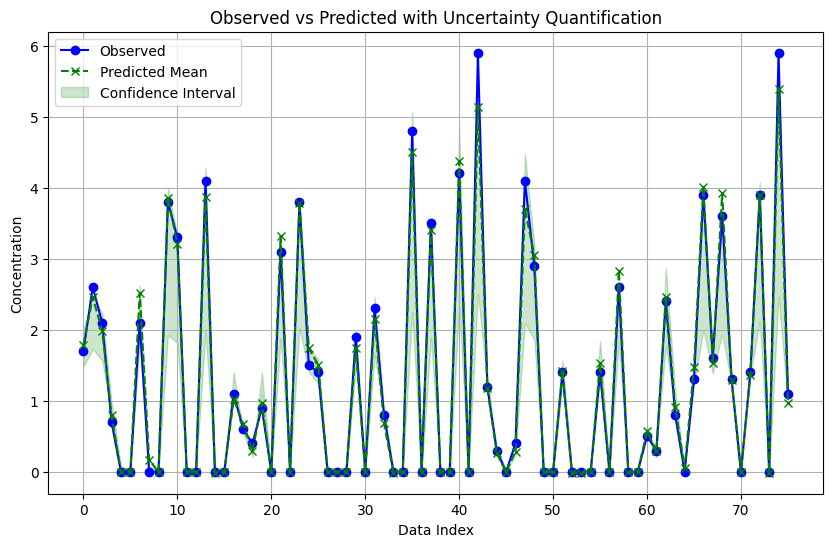

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# 加载数据
data_file_path = 'observed_and_predictions_prev.csv'
data = pd.read_csv(data_file_path)

observed = data['Observed (prev)']
predicted_mean = data['Predicted Mean (prev)']
lower_bound = data['Lower Bound (prev)']
upper_bound = data['Upper Bound (prev)']

# 绘制置信区间图
plt.figure(figsize=(10, 6))
plt.plot(observed, label='Observed', color='blue', marker='o')
plt.plot(predicted_mean, label='Predicted Mean', color='green', linestyle='--', marker='x')
plt.fill_between(range(len(predicted_mean)), lower_bound, upper_bound, color='green', alpha=0.2, label='Confidence Interval')

plt.xlabel('Data Index')
plt.ylabel('Concentration')
plt.title('Observed vs Predicted with Uncertainty Quantification')
plt.legend()
plt.grid(True)
plt.show()
